# Carga de librerias y dataframe

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

In [ ]:
df = pd.read_csv('avocado_clean.csv')

In [ ]:
df['Date'] = df['Date'].astype('datetime64[ns]')

# Correlaciones entre variables

Antes de empezar, para esta actividad se excluyó la columna de regiones ('region') debido a contiene demasiados valores como para analizarlos visualmente. Además, la correlación utilizando cada region suele ser baja (0.0 - 0.2) para cada variable, por lo que incluirlas solo afectaría los resultados.

In [ ]:
df_dummies.head()

,Date,AveragePrice,Total Volume,4046,4225,Total Bags,Small Bags,region,type_organic
0,2015-12-27,1.33,64236.62,1036.74,54454.85,8696.87,8603.62,Albany,False
1,2015-12-20,1.35,54876.98,674.28,44638.81,9505.56,9408.07,Albany,False
2,2015-12-13,0.93,118220.22,794.70,109149.67,8145.35,8042.21,Albany,False
3,2015-12-06,1.08,78992.15,1132.00,71976.41,5811.16,5677.40,Albany,False
4,2015-11-29,1.28,51039.60,941.48,43838.39,6183.95,5986.26,Albany,False


In [ ]:
df_dummies = pd.get_dummies(df, columns=['type'], drop_first=True)

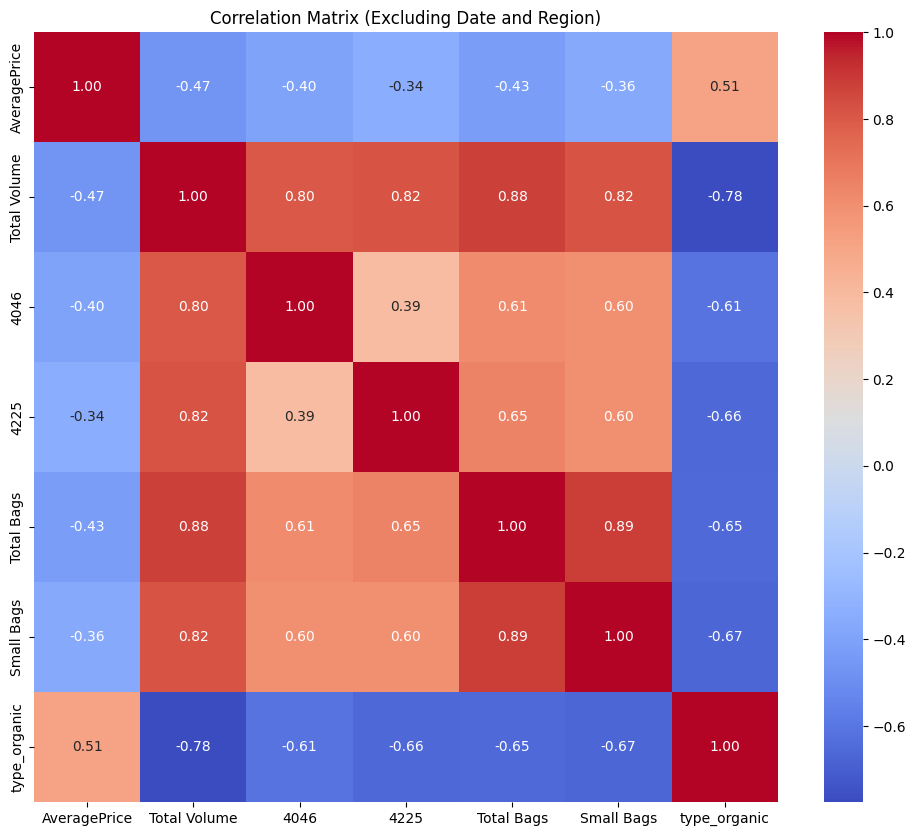

In [ ]:
correlation_matrix = df_dummies.drop(['Date', 'region'], axis=1).corr()
plt.figure(figsize=(12, 10))
sn.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Excluding Date and Region)')
plt.show()

Para empezar, se observa que Average price muestra una correlación negativa para todas las variables excepto, type_organic. Esto es de esperarse ya que entre más volumen se haya vendido, lo normal es esperar que sea porque el precio era barato, y viceversa. Para el tipo de aguacate, se observa un valor mayor para aguacates organicos.

Para Total Volume, se observa una gran correlacion entre el volumen vendido de los demás aguacates y bolsas, y una negativa con respecto al tipo de aguacate. De nuevo, aquí se puede observar una clara colinealidad, ya que en si el volumen total es la suma de venta de todos las variades de aguacates (4046, 4225. En este caso, se eliminó anteriormente la variedad 4770). Si el Aguacate es orgánico, se espera un menor volumen de venta (Esto ya se había observado en anteriores actividades)

Para el volumen de venta de aguacate 4046, se observa una correlacion positiva con la variedad 4225, el total de bolsas vendidas y la cantidad de bolsas pequeñas vendidas. Que el total de bolsas vendidas sea directamente proporcional es de esperarse. En cuanto al tipo de aguacate, se tiene un coeficiente negativo.

Parala variante 4225, se observan características similares a las observadas en la variedad 4046.

En cuanto al total de bolsas, la correlación positiva con las bolsas pequeñas es completamente esperado y es colineal. Sin emabargo, el factor de correlación es negativo para el tipo de aguacate.

Por último, se observa una correlación negativa entre la venta de bolsas pequeñas y el tipo orgánico.

Para observar la relación entre las demás variables con el transcurso del tiempo, se obtuvo el promedio obtenido en cada día de cada variable, ya que usualmente hay información repetida cada día para cada región.



In [ ]:
daily_avg_df = df.groupby('Date').mean(numeric_only=True).reset_index()
display(daily_avg_df.head())

,Date,AveragePrice,Total Volume,4046,4225,Total Bags,Small Bags
0,2015-01-04,1.458082,56877.936164,21037.432055,20411.174110,12613.493288,10251.013973
1,2015-01-11,1.507867,57483.579333,20790.800667,20599.225733,13010.113733,10264.573467
2,2015-01-18,1.522703,52323.519189,17411.634595,20101.925946,12956.363919,10033.555946
3,2015-01-25,1.547361,47756.546667,16608.294167,17314.094722,12127.031250,9581.129722
4,2015-02-01,1.444687,48856.947656,16159.000469,19576.109219,9432.474531,6933.344063


In [ ]:
all_columns_daily = daily_avg_df.columns.tolist()
columns_to_plot_daily = [col for col in all_columns_daily if col != 'Date']
print(columns_to_plot_daily)

['AveragePrice', 'Total Volume', '4046', '4225', 'Total Bags', 'Small Bags']


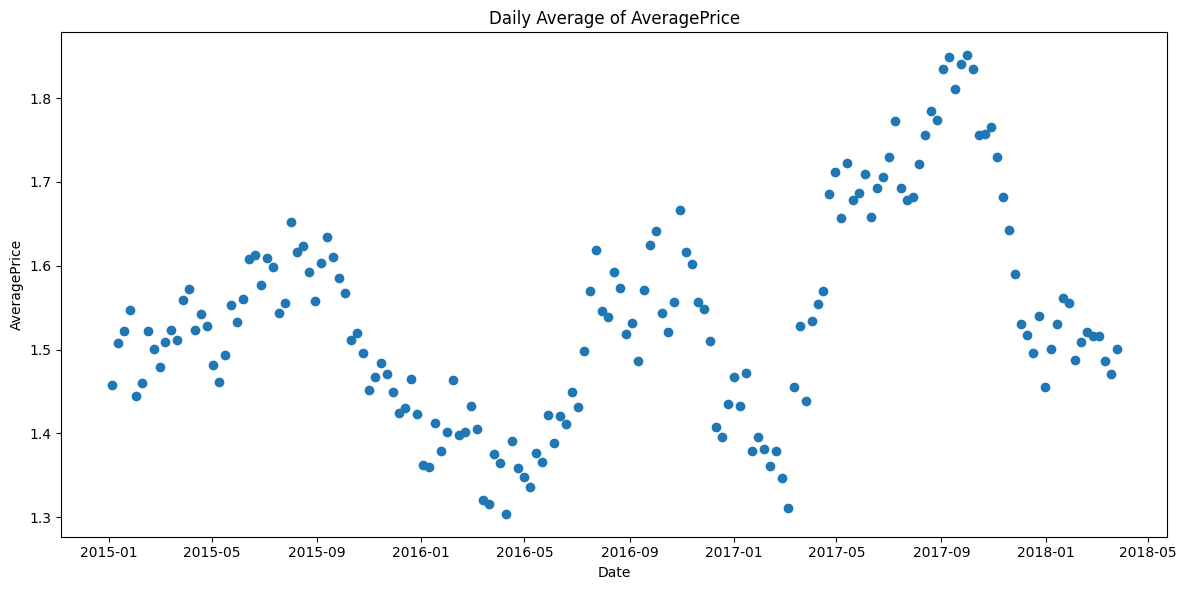

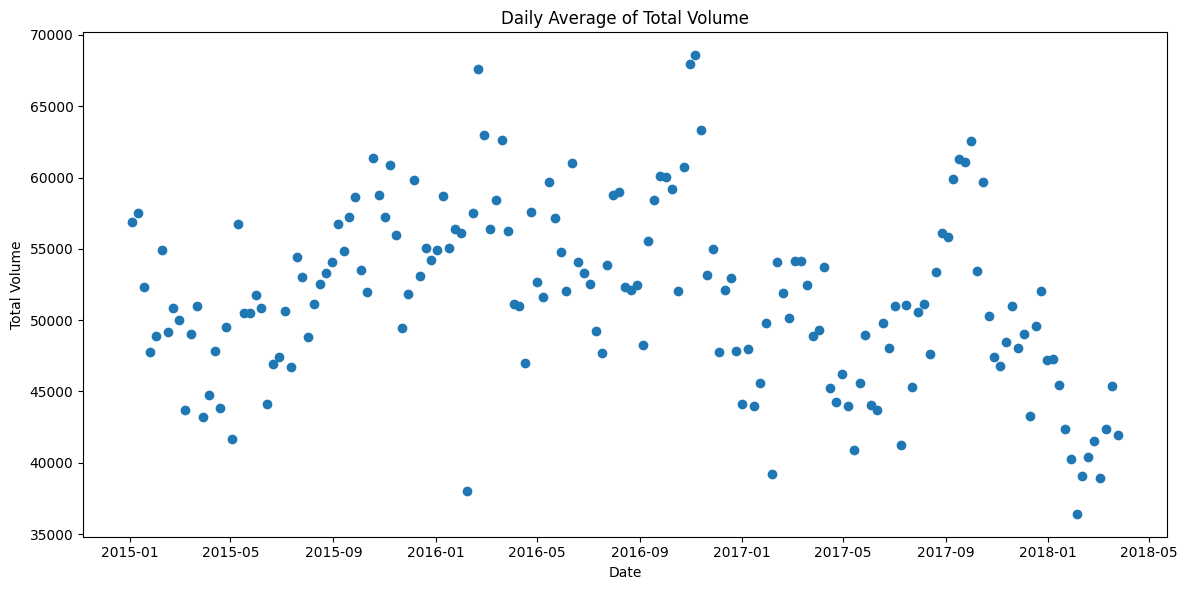

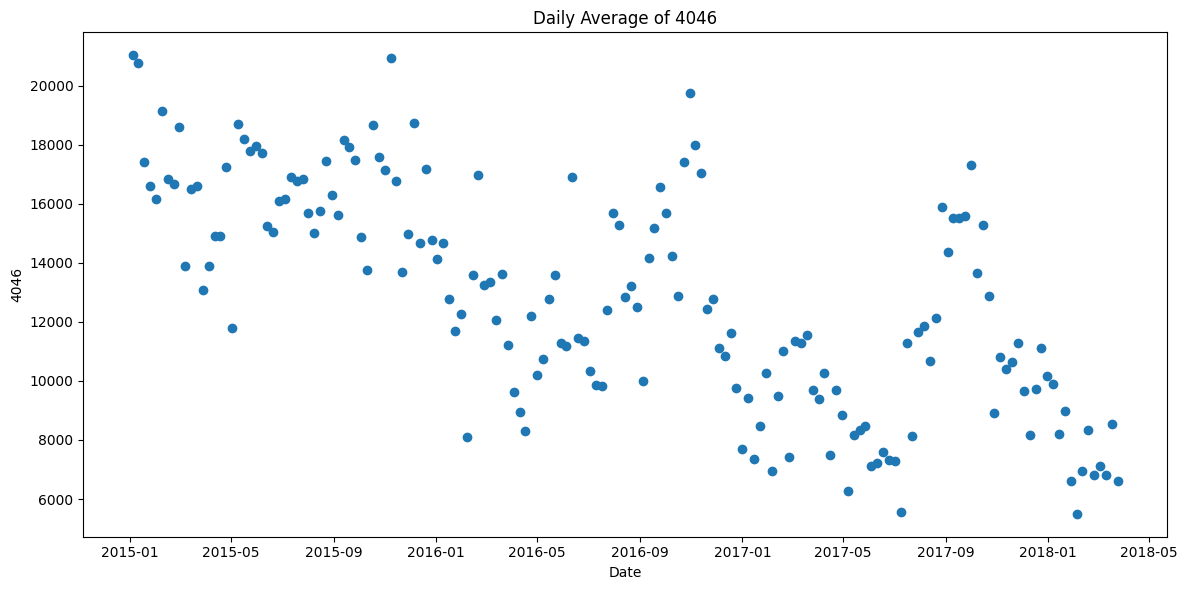

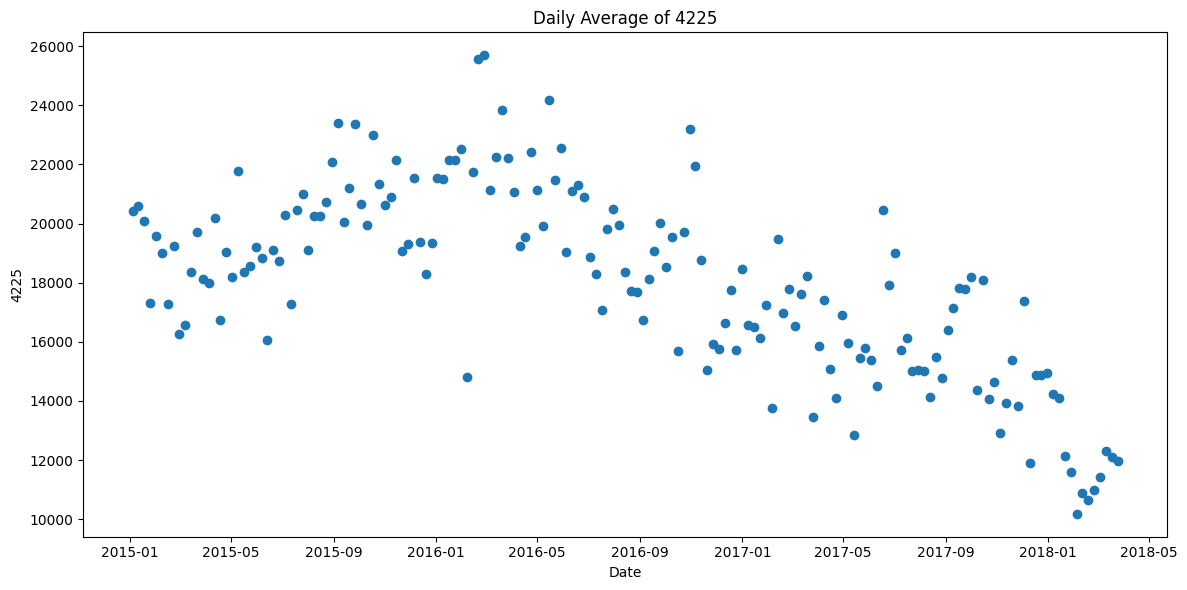

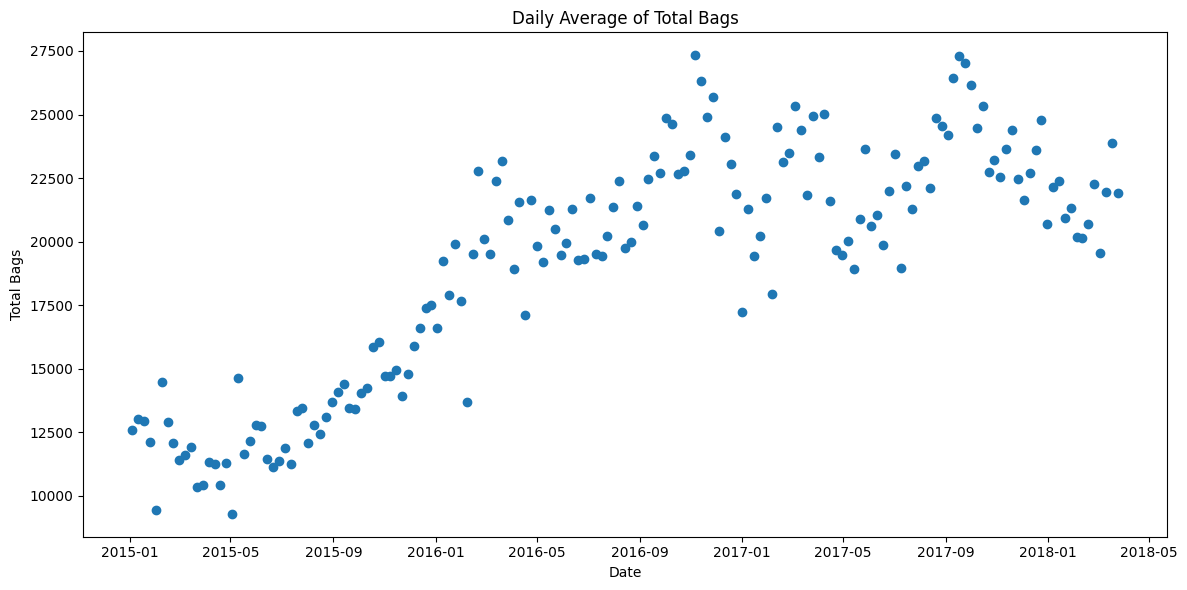

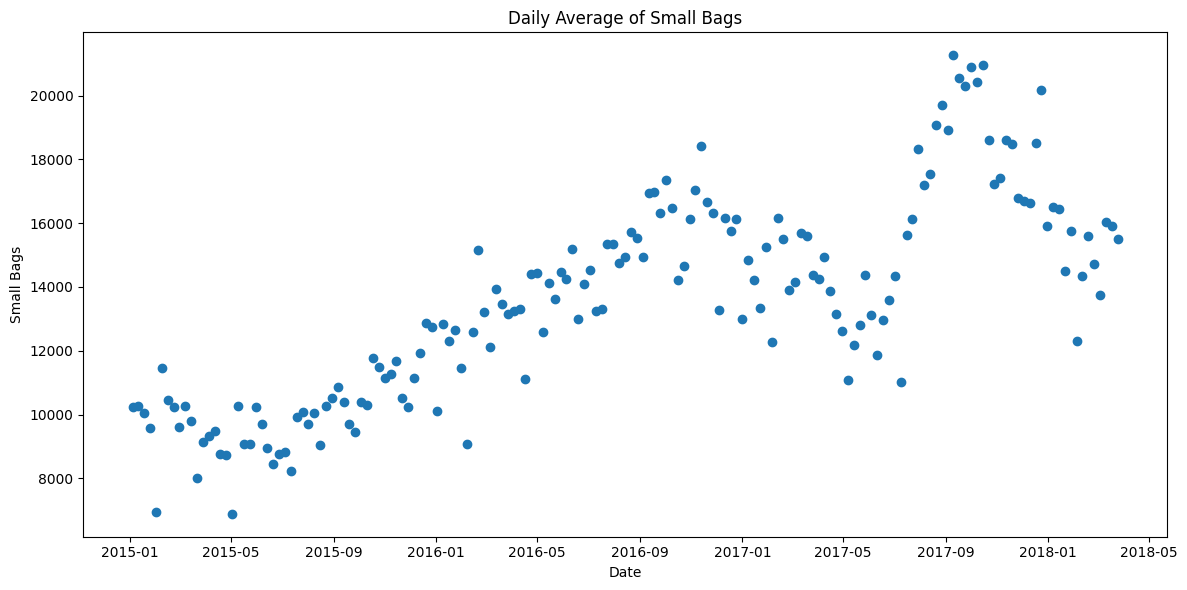

In [ ]:
for column_name in columns_to_plot_daily:
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.scatter(daily_avg_df['Date'], daily_avg_df[column_name])
    ax.set_title(f'Daily Average of {column_name}')
    ax.set_xlabel('Date')
    ax.set_ylabel(column_name)
    plt.tight_layout()
    plt.show()

Se observa que por lo general el volumen de total vendido y para cada variedad de aguacate disminuye conforme pasa el tiempo, o sea se observa una correlación negativa.

Sorprendementemente, se observa un aumento en las ventas totales de bolsas y de solo bolsas pequeñas. Puede indicar que cada vez había menos aguacates en cada una de las bolsas, por lo que la venta de bolsas tuvo que aumentar para compensar dicha diferencia.

No se puede determinar con tanta facilidad, por lo menos de forma visual, la tendencia real del precio promedio de los aguacates: Es complicado saber si tiende a subir o no debido a las grandes variaciones de precios. Por lo menos, se sabe que el precio promedio tuvo un pico a finales de 2017.

# Regresión lineal simple (utilizando como variable dependiente el tiempo)

Se hara una regresión lineal para todas las anteriores variables mostradas

In [ ]:
daily_avg_df['Date_numeric'] = daily_avg_df['Date'].astype('int64') // 10**9

,Date,AveragePrice,Total Volume,4046,4225,Total Bags,Small Bags,Date_numeric
0,2015-01-04,1.458082,56877.936164,21037.432055,20411.174110,12613.493288,10251.013973,1420329600
1,2015-01-11,1.507867,57483.579333,20790.800667,20599.225733,13010.113733,10264.573467,1420934400
2,2015-01-18,1.522703,52323.519189,17411.634595,20101.925946,12956.363919,10033.555946,1421539200
3,2015-01-25,1.547361,47756.546667,16608.294167,17314.094722,12127.031250,9581.129722,1422144000
4,2015-02-01,1.444687,48856.947656,16159.000469,19576.109219,9432.474531,6933.344063,1422748800


In [ ]:
all_columns_daily = daily_avg_df.columns.tolist()
dependent_variables = [col for col in all_columns_daily if col not in ['Date', 'Date_numeric']]
print(dependent_variables)

['AveragePrice', 'Total Volume', '4046', '4225', 'Total Bags', 'Small Bags']



Performing linear regression for: AveragePrice
                            OLS Regression Results                            
Dep. Variable:           AveragePrice   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.112
Method:                 Least Squares   F-statistic:                     22.19
Date:                Sun, 05 Oct 2025   Prob (F-statistic):           5.17e-06
Time:                        04:10:17   Log-Likelihood:                 123.56
No. Observations:                 169   AIC:                            -243.1
Df Residuals:                     167   BIC:                            -236.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------


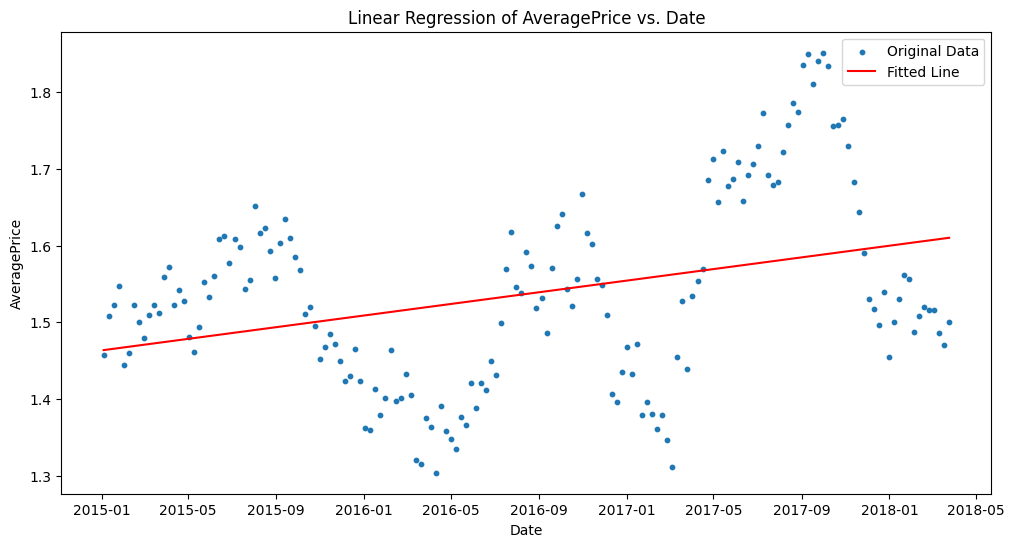


Performing linear regression for: Total Volume
                            OLS Regression Results                            
Dep. Variable:           Total Volume   R-squared:                       0.066
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     11.75
Date:                Sun, 05 Oct 2025   Prob (F-statistic):           0.000766
Time:                        04:10:17   Log-Likelihood:                -1709.6
No. Observations:                 169   AIC:                             3423.
Df Residuals:                     167   BIC:                             3429.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------


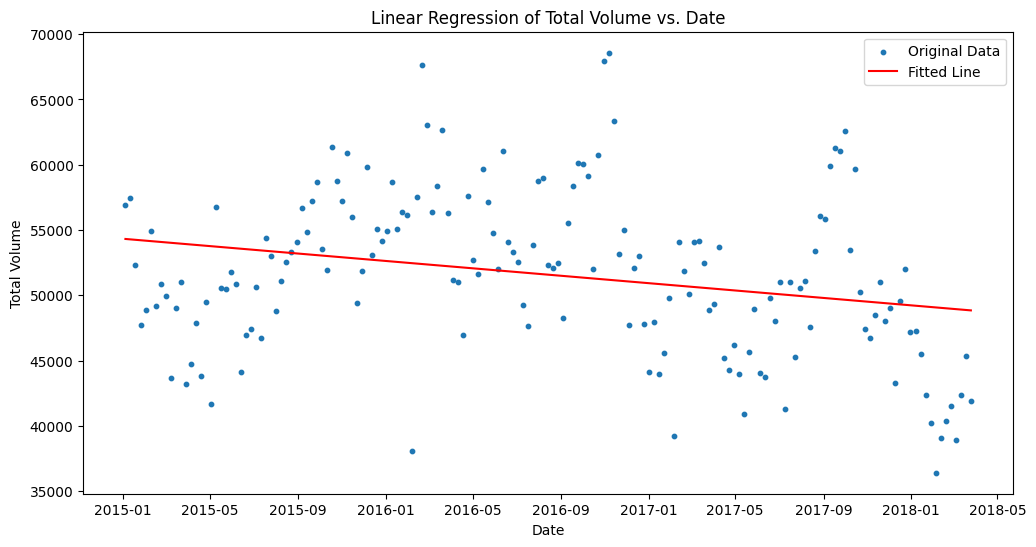


Performing linear regression for: 4046
                            OLS Regression Results                            
Dep. Variable:                   4046   R-squared:                       0.486
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     158.0
Date:                Sun, 05 Oct 2025   Prob (F-statistic):           6.31e-26
Time:                        04:10:17   Log-Likelihood:                -1574.2
No. Observations:                 169   AIC:                             3152.
Df Residuals:                     167   BIC:                             3159.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const   

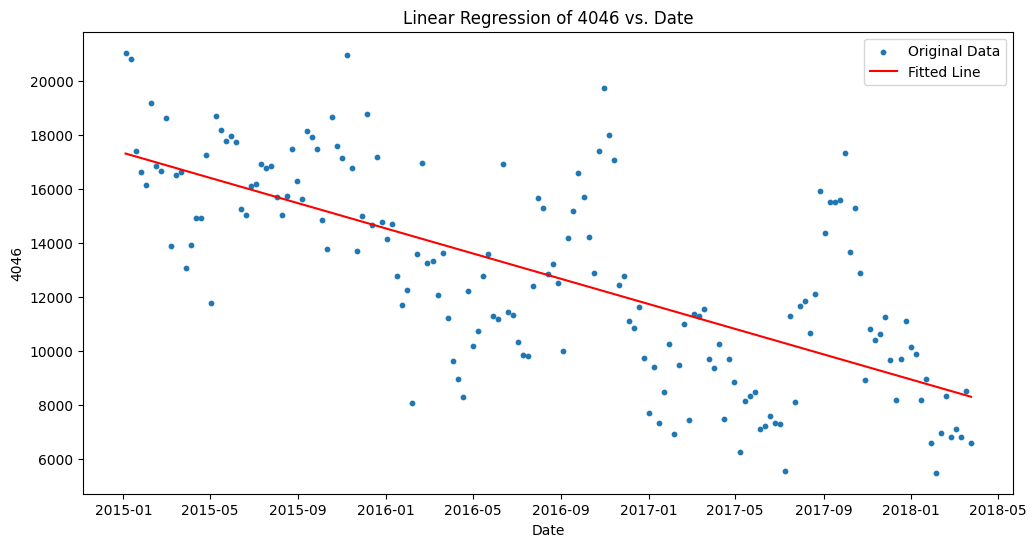


Performing linear regression for: 4225
                            OLS Regression Results                            
Dep. Variable:                   4225   R-squared:                       0.450
Model:                            OLS   Adj. R-squared:                  0.447
Method:                 Least Squares   F-statistic:                     136.7
Date:                Sun, 05 Oct 2025   Prob (F-statistic):           1.88e-23
Time:                        04:10:18   Log-Likelihood:                -1551.6
No. Observations:                 169   AIC:                             3107.
Df Residuals:                     167   BIC:                             3113.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const   

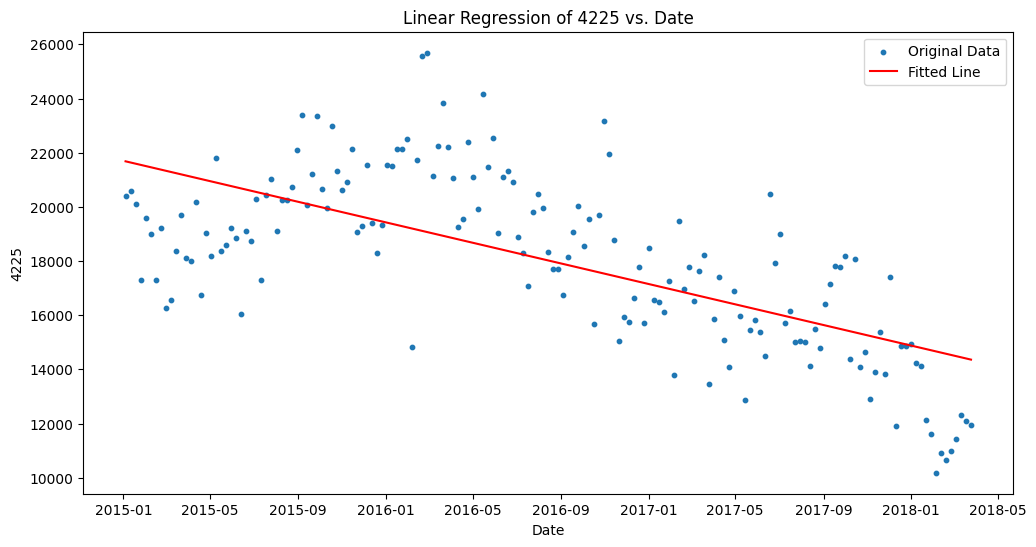


Performing linear regression for: Total Bags
                            OLS Regression Results                            
Dep. Variable:             Total Bags   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.680
Method:                 Least Squares   F-statistic:                     358.4
Date:                Sun, 05 Oct 2025   Prob (F-statistic):           2.02e-43
Time:                        04:10:18   Log-Likelihood:                -1570.3
No. Observations:                 169   AIC:                             3145.
Df Residuals:                     167   BIC:                             3151.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
co

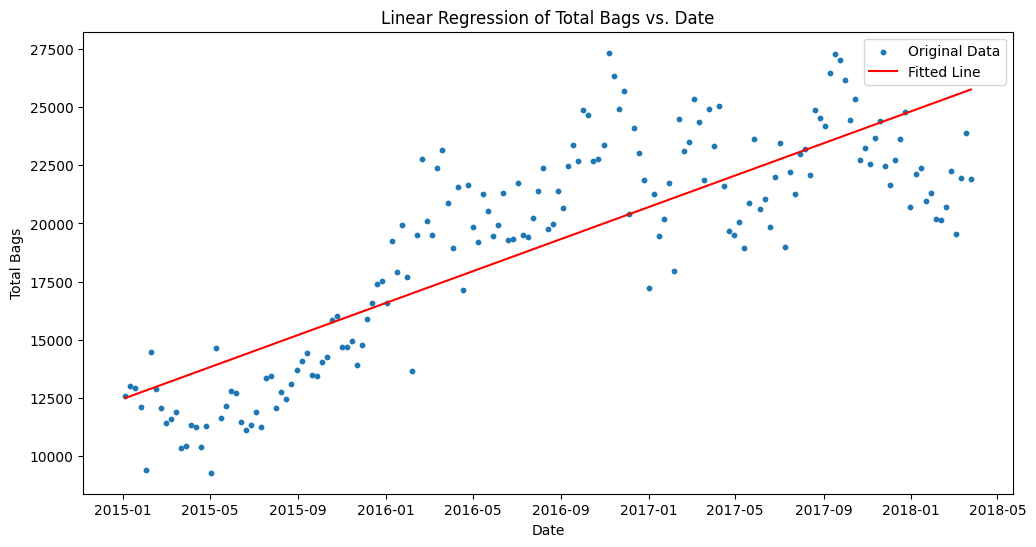


Performing linear regression for: Small Bags
                            OLS Regression Results                            
Dep. Variable:             Small Bags   R-squared:                       0.641
Model:                            OLS   Adj. R-squared:                  0.639
Method:                 Least Squares   F-statistic:                     298.0
Date:                Sun, 05 Oct 2025   Prob (F-statistic):           5.60e-39
Time:                        04:10:18   Log-Likelihood:                -1517.5
No. Observations:                 169   AIC:                             3039.
Df Residuals:                     167   BIC:                             3045.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
co

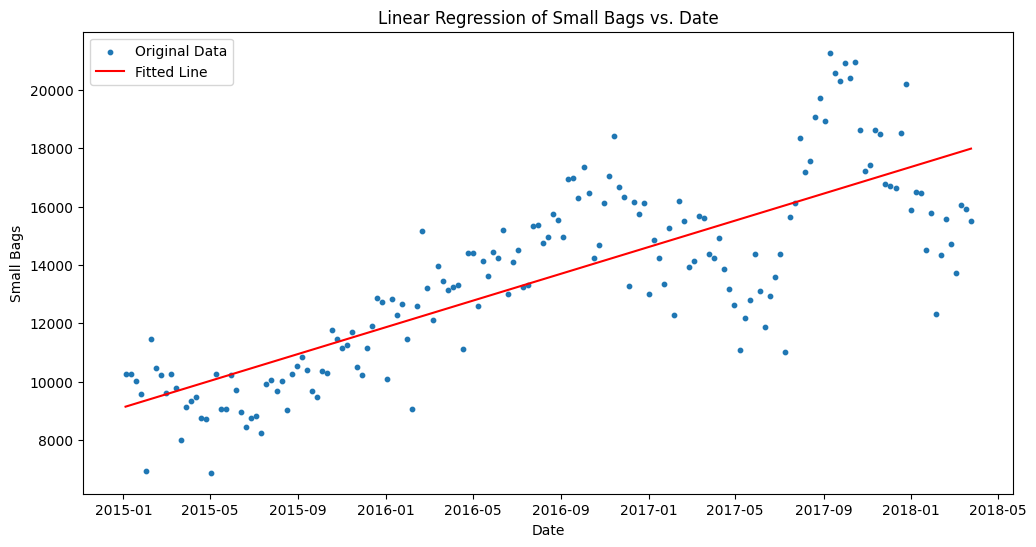

In [ ]:
import statsmodels.api as sm

dependent_variables = ['AveragePrice', 'Total Volume', '4046', '4225', 'Total Bags', 'Small Bags']

for column_name in dependent_variables:
    print(f"\nPerforming linear regression for: {column_name}")

    # Define independent and dependent variables
    X = daily_avg_df['Date_numeric']
    y = daily_avg_df[column_name]

    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Create and fit the OLS model
    model = sm.OLS(y, X)
    results = model.fit()

    # Print the regression results
    print(results.summary())

    # Plotting the results
    plt.figure(figsize=(12, 6))
    plt.scatter(daily_avg_df['Date'], y, label='Original Data', s=10)
    plt.plot(daily_avg_df['Date'], results.predict(X), color='red', label='Fitted Line')
    plt.title(f'Linear Regression of {column_name} vs. Date')
    plt.xlabel('Date')
    plt.ylabel(column_name)
    plt.legend()
    plt.show()

Analizanado el valor de las R^2 de cada regresión, se puede concluir que solo las últimas cuatro muestran una fuerte dependencia lineal en torno al tiempo, al tener valores de R^2 mayores a 0.4.

# Regresion lineal múltiple

In [ ]:
import statsmodels.api as sm

df_dummies = pd.get_dummies(df, columns=['type', 'region'], drop_first=True)


bool_cols = df_dummies.select_dtypes(include=['bool']).columns
df_dummies[bool_cols] = df_dummies[bool_cols].astype(int)

# Drop 'Date' and 'region' columns from the DataFrame for the multiple regression analysis
df_mlr = df_dummies.drop(['Date'], axis=1)

# Get the list of columns to use as dependent variables (all except 'Date', 'region', and 'type_organic')
dependent_variables_mlr = ['AveragePrice', 'Total Volume', '4046', '4225', 'Total Bags',
       'Small Bags']



for dependent_var in dependent_variables_mlr:
    print(f" \n\n### Performing multiple linear regression with {dependent_var} as the dependent variable ###\n\n")

    # Define the dependent variable (y) and independent variables (X)
    y_mlr = df_mlr[dependent_var]
    X_mlr = df_mlr.drop(dependent_var, axis=1)

    # Add a constant to the independent variables
    X_mlr = sm.add_constant(X_mlr)

    # Create and fit the OLS model
    model_mlr = sm.OLS(y_mlr, X_mlr)
    results_mlr = model_mlr.fit()

    # Print the regression results
    print(results_mlr.summary())

 

###Performing multiple linear regression with AveragePrice as the dependent variable ###


                            OLS Regression Results                            
Dep. Variable:           AveragePrice   R-squared:                       0.508
Model:                            OLS   Adj. R-squared:                  0.505
Method:                 Least Squares   F-statistic:                     193.7
Date:                Mon, 20 Oct 2025   Prob (F-statistic):               0.00
Time:                        21:17:10   Log-Likelihood:                -475.43
No. Observations:               10950   AIC:                             1069.
Df Residuals:                   10891   BIC:                             1500.
Df Model:                          58                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------

En general, se obtuvieron bueno indices de r^2 en todas las regresiones realizadas, aunque en donde se obtuvieron mejores predicciones fue justamente al momento de predecir el volumen de aguacates vendidos, tanto individuales como en bolsa, y de cada tipo. Esto es debido a que al usar como variables independientes otras métricas de volumen vendido, estás influiran en las predicción realizada, justamente al intentar predecir el volumen total, se asignó un coeficiente aproximadamente de 1 a el aguacate del tipo 4046 y 4225, ya que falta un tipo de aguacate que se eliminó en la fase de limpieza de datos (práctica 1)